In [ ]:
import trainer_tools.all as tt
from trainer_tools.all import *
from graph_attention.all import *

In [ ]:
tt.configure_logging()

<RootLogger root (INFO)>

In [ ]:
import torchvision.transforms as tfm

transforms = default_cifar_train_tfms[:-1] + [
    tfm.TrivialAugmentWide(),
    tfm.ToTensor(),
]

In [ ]:
BS = 64
variant = 'cifar10'


ds = get_cifar(root="../data", train=True, variant=variant, transforms=transforms)
valid_ds = get_cifar(root="../data", train=False, variant=variant)
dl_kwargs = dict(num_workers=6, persistent_workers=True)
train_dl = DataLoader(ds, batch_size=BS, shuffle=True, **dl_kwargs)
valid_dl = DataLoader(valid_ds, batch_size=BS * 2, shuffle=False, **dl_kwargs)

100%|██████████| 170M/170M [00:22<00:00, 7.57MB/s] 


In [ ]:
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 500
GRAD_CLIP_MAX_NORM = 1.0
AMP_ENABLED = True
CHECKPOINT_EVERY = 1000
SAVE_DIR = "../checkpoints/vit_cifar100"

model = SimpleViT(
    image_size=32,
    patch_size=4,
    num_classes=len(ds.classes),
    dim=256,
    depth=6,
    heads=4,
    mlp_dim=512,
    channels=3,
    dim_head=64
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [ ]:
loss_func = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

total_steps = len(train_dl) * EPOCHS


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    total_steps=len(train_dl) * EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=100.0
)

hooks = [
    ProgressBarHook(),
    AccuracyMetricsHook(verbose=True),
    LRSchedulerHook(scheduler, step_on_batch=True),
    AMPHook(enabled=AMP_ENABLED),
    GradClipHook(max_norm=GRAD_CLIP_MAX_NORM),
    EMAHook(),
    CheckpointHook(
        save_dir=SAVE_DIR,
        save_every_steps=CHECKPOINT_EVERY,
        keep_last=3
    ),
]

trainer = BaseTrainer(
    model=model,
    train_dl=train_dl,
    valid_dl=valid_dl,
    optim=optimizer,
    loss_func=loss_func,
    epochs=EPOCHS,
    hooks=hooks
)

In [ ]:
trainer.fit()

Epoch:   0%|          | 0/30 [00:00<?, ?it/s]

18:37:51 [INFO] trainer_tools.hooks.optimization: Mixed Precision Training: Enabled


Epoch 1/30 [Train]:   0%|          | 0/782 [00:10<?, ?it/s]

Epoch 1/30 [Valid]:   0%|          | 0/79 [00:09<?, ?it/s]

18:38:28 [INFO] trainer_tools.hooks.metrics: Epoch 1/30 | Train Loss: 2.0037 | Val Loss: 2.3662


...

18:46:44 [INFO] trainer_tools.hooks.metrics: Epoch 29/30 | Train Loss: 1.2956 | Val Loss: 1.1737


Epoch 30/30 [Train]:   0%|          | 0/782 [00:00<?, ?it/s]

18:46:51 [INFO] trainer_tools.hooks.checkpoint: Saved checkpoint: ../checkpoints/vit_cifar100/checkpoint_step_23000.pt


Epoch 30/30 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

18:47:01 [INFO] trainer_tools.hooks.metrics: Epoch 30/30 | Train Loss: 1.2948 | Val Loss: 1.1662
18:47:01 [INFO] trainer_tools.hooks.checkpoint: Saved checkpoint: ../checkpoints/vit_cifar100/model_final.pt
18:47:01 [INFO] trainer_tools.hooks.checkpoint: Using EMA model for pretrained export
18:47:01 [INFO] trainer_tools.checkpoint: Saved model to ../checkpoints/vit_cifar100/model.pt


array([<Axes: title={'center': 'Accuracy'}>,
       <Axes: title={'center': 'Loss'}, xlabel='Batch / Step'>],
      dtype=object)

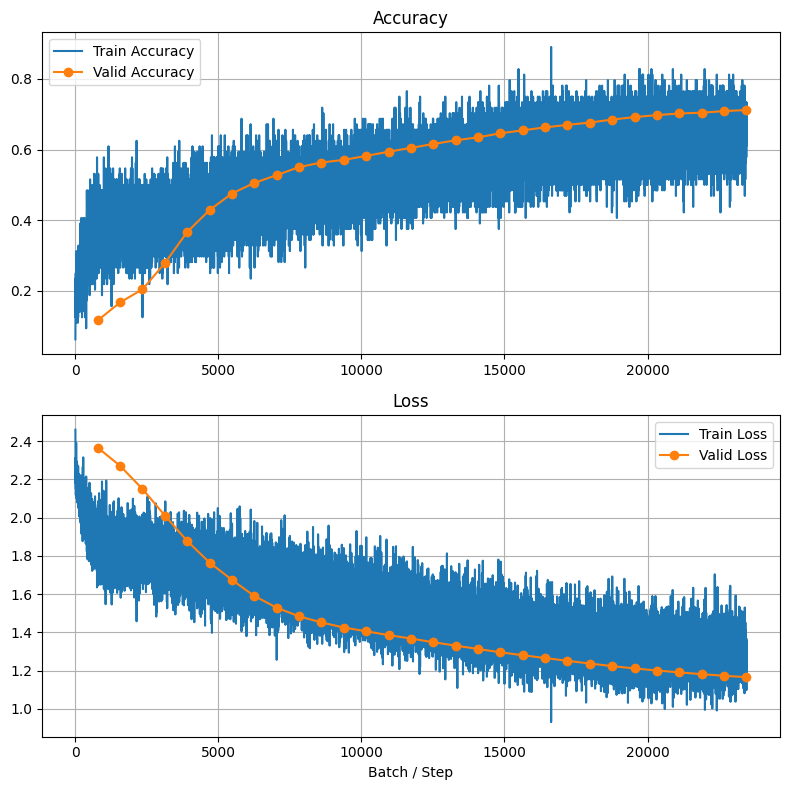

In [ ]:
trainer.get_hook(MetricsHook).plot_loss()